# XAI User Study: Reading vs Recall

## Overview

This notebook tests whether explanations help people predict an AI model's output.

- **Between participants:** SHAP, LIME, LRP, or no explanation
- **Within participants:** explanation visible (**Reading**) or hidden (**Recall**)
- **Task:** predict the AI label
- **Primary measure:** forward-simulation accuracy
- **Dataset:** Wine Quality with five numeric features

> The notebook runs a virtual baseline to check the design. It does not replace a human study.


## Human study flow

Consent → tutorial → comprehension check → training with feedback → Reading/Recall testing → workload questionnaire → debrief.


## What the user model represents

A cognition-oriented user model can represent:

- **Memory:** which training examples are remembered
- **Attention:** which features or explanation values are used
- **Strategy:** how evidence is combined into a prediction
- **Reading vs Recall:** whether the explanation is available at test time

This notebook uses KNN as a simple nearest-example memory baseline. A fuller user model can be added later without changing the study design or trial table.


## Step 1 — Setup

Import the toolkit and create one experiment object.


In [27]:
from pathlib import Path
import sys

import pandas as pd

repo_root = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src" / "api.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.api as xk

xaikitTest = xk.xaikitTest(
    project_name="xai_comparison_user_study",
    output_dir=".",
)


## Step 2 — Define the study

Compare explanation methods between participants and Reading/Recall within participants.


In [28]:
xaikitTest.add_iv("xai_method", "between", ["shap", "lime", "lrp", "none"])
xaikitTest.add_iv(
    "tested_w_xai",
    "within",
    [True, False],
    randomization="trial",
)
xaikitTest.add_cv("user_task", ["forward_simulation"])
xaikitTest.add_dv("forward_accuracy", ["continuous"])

xaikitTest.validate(stage="design", show=True)


XAIKit validation: design

Normalized:
  IVs:
    xai_method: shap, lime, lrp, none
    tested_w_xai: True, False
  Semantic CVs:
    user_task: forward_simulation
  DVs: forward_accuracy
  CVs: user_task
  Context:
    dataset_id: not set
    model_name: not set
    model_source: not set
    cognitive_model_id: placeholder
    tasks: forward_simulation
    xai_methods: shap, lime, lrp, none
    xai_types: not set
    xai_faithfulness: not set
    dvs: forward_accuracy

## Step 3 — Prepare the dataset

Use the same five features and data split throughout the study.


In [29]:
data = xaikitTest.prepare_dataset(
    "wine_quality",
    feature_cols=["Alcohol", "Sulphates", "SO2", "Vinegar Taint", "pH"],
    num_features=5,
    rank_features_by_target=True,
    test_size=0.2,
    random_state=42,
)


Available training datasets: ['adult', 'breast_cancer', 'cardiotocography', 'forest_cover', 'heart_disease', 'king_county_housing', 'mushrooms', 'prima_diabetes', 'wine_quality']
Dataset   : wine_quality  (1599 rows, 5 model features)
Features  : ['Alcohol', 'Vinegar Taint', 'Sulphates', 'SO2', 'pH']
Encoding  : one-hot
Train set : 1279 samples  (80%)
Test set  : 320 samples  (20%)
Class balance (train) -> class 0: 1105
Class balance (train) -> class 1: 174
First test instanceIds: [434, 213, 1447, 231, 763, 1472, 472, 1327, 766, 19]


## Step 4 — Set participant and trial counts

Each explanation condition receives 25 virtual participants. Every participant completes 10 training and 20 testing trials.


In [30]:
trial_settings = {
    "participants_per_between_condition": 25,
    "num_training": 10,
    "num_testing": 20,
    "output_dir": "experiment_output",
    "seed": 42,
    "preview_rows": 5,
}
trial_settings


{'participants_per_between_condition': 25,
 'num_training': 10,
 'num_testing': 20,
 'output_dir': 'experiment_output',
 'seed': 42,
 'preview_rows': 5}

## Step 5 — Train the AI and create trials

Train the model first, then sample an equal number of both predicted labels in each phase.


In [31]:
model = xaikitTest.train_AI_model(
    model_type="mlp",
    target_metric="accuracy",
    target_score=0.90,
    max_epochs=1000,
    check_every_epochs=10,
    batch_size=100,
    verbose=False,
)

xaikitTest.validate(stage="trial_generation", show=True)
trial_result = xaikitTest.generate_trials(
    **trial_settings,
    balance_by_ai_prediction=True,
)
trial_table = pd.DataFrame(trial_result.trials)

prediction_balance = (
    trial_table.groupby(["phase", "sampled_ai_prediction"])
    .size()
    .rename("trials")
    .reset_index()
)

display(xaikitTest.training_summary_table())
display(prediction_balance)
display(trial_table.head())


Counterbalancing strategy: complete_counterbalancing
Participant assignments: 100 total
Instance pool rows: 300
Trial rows: 3000
Exported trial artifacts:
  CSV     : experiment_output/trials.csv
  JSON    : experiment_output/trials.json
  Summary : experiment_output/design_summary.json

Previewing first 5 trial rows:
{'participantId': 1, 'trialId': 1, 'phase': 'training', 'phaseTrialId': 1, 'block': 1, 'trialWithinBlock': 1, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'dataId': 'wine_quality', 'instanceId': '341', 'sampled_ai_prediction': 1}
{'participantId': 1, 'trialId': 2, 'phase': 'training', 'phaseTrialId': 2, 'block': 1, 'trialWithinBlock': 2, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'dataId': 'wine_quality', 'instanceId': '1185', 'sampled_ai_prediction': 0}
{'participantId': 1, 'trialId': 3, 'phase': 'training', 'phaseTrialId': 3, 'block': 1, 'trialWithinBlock': 3, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'dataId': 'wine_

,target_metric,target_score,final_score,epochs,batch_size,reached_target,target_accuracy,final_accuracy,model_type,dataset
0,accuracy,0.9,0.900704,230,100,True,0.9,0.900704,mlp,wine_quality


,phase,sampled_ai_prediction,trials
0,testing,0,1000
1,testing,1,1000
2,training,0,500
3,training,1,500


,participantId,trialId,block,trialWithinBlock,withinCondition,xai_method,dataId,instanceId,CV_user_task_levels,phase,phaseTrialId,sampled_ai_prediction,tested_w_xai
0,1,1,1,1,single_condition,shap,wine_quality,341,forward_simulation,training,1,1,NaN
1,1,2,1,2,single_condition,shap,wine_quality,1185,forward_simulation,training,2,0,NaN
2,1,3,1,3,single_condition,shap,wine_quality,1083,forward_simulation,training,3,0,NaN
3,1,4,1,4,single_condition,shap,wine_quality,1402,forward_simulation,training,4,1,NaN
4,1,5,1,5,single_condition,shap,wine_quality,1005,forward_simulation,training,5,1,NaN


## Step 6 — Check the AI model

Confirm that the AI performs well enough to be studied.


Test accuracy: 0.913


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
train,0.900704,0.710111,0.715596,0.448276,0.551237,0.919462,0.655345,0.816773,0.710111,0.747706,0.890420,0.900704,0.890719
test,0.912500,0.694064,0.894737,0.395349,0.548387,0.858282,0.700246,0.904179,0.694064,0.749972,0.911084,0.912500,0.897381


,predicted_0,predicted_1
actual_0,275,2
actual_1,26,17


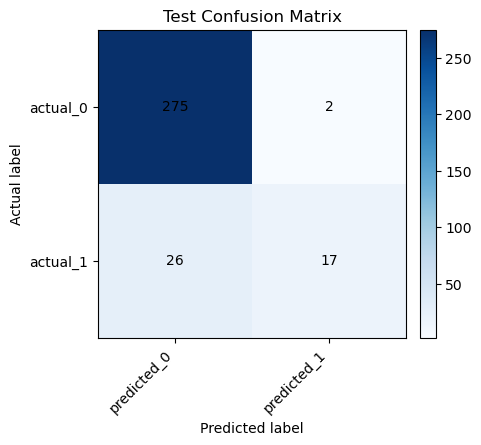

In [32]:
xaikitTest.evaluate(split="both", positive_label=1, threshold=0.5)

print(f"Test accuracy: {xaikitTest.test_accuracy():.3f}")
display(xaikitTest.metrics_table())
display(xaikitTest.confusion_matrix_table(split="test"))
xaikitTest.plot_confusion_matrix(split="test");


## Step 7 — Generate explanations

Create explanation files for the trials where XAI is shown.


In [33]:
combined_path, combined_df = xaikitTest.explanations(
    output_dir="generated_explanation",
    target=1,
    method_kwargs={
        "shap": {"n_background_samples": 30},
        "lime": {"num_samples": 1000},
    },
)

method_counts = (
    combined_df["expMethod"]
    .value_counts()
    .rename_axis("method")
    .reset_index(name="rows")
)

print(f"Saved explanations: {combined_path}")
display(method_counts)


Using stored XAI methods from the design: ['shap', 'lime', 'lrp', 'none']
Using stored model name for explanation files: 'mlp'

Generating explanations for xai method: shap
  Sampled instances: 306


  0%|          | 0/306 [00:00<?, ?it/s]

  Saved: generated_explanation/shap_mlp_wine_quality.csv shape=(306, 12)

Generating explanations for xai method: lime
  Sampled instances: 322
  Saved: generated_explanation/lime_mlp_wine_quality.csv shape=(322, 12)

Generating explanations for xai method: lrp
  Sampled instances: 309
  Saved: generated_explanation/lrp_mlp_wine_quality.csv shape=(309, 12)
Skipping explanation generation for xai method: none

Saved complete AI prediction table: generated_explanation/predictions_mlp_wine_quality.csv shape=(1599, 5)

Combined explanation CSV: generated_explanation/de_mlp_wine_quality.csv shape=(2536, 12)
Saved explanations: generated_explanation/de_mlp_wine_quality.csv


,method,rows
0,__prediction_only__,1599
1,lime,322
2,lrp,309
3,shap,306


## Step 8 — Preview the study

Inspect one explanation, then walk through one participant's trials.


(<Figure size 850x435 with 4 Axes>,
 array([<AxesSubplot:title={'center':'Attribute'}>,
        <AxesSubplot:title={'center':'Value'}>, <AxesSubplot:>,
        <AxesSubplot:title={'center':'Importance'}>], dtype=object))

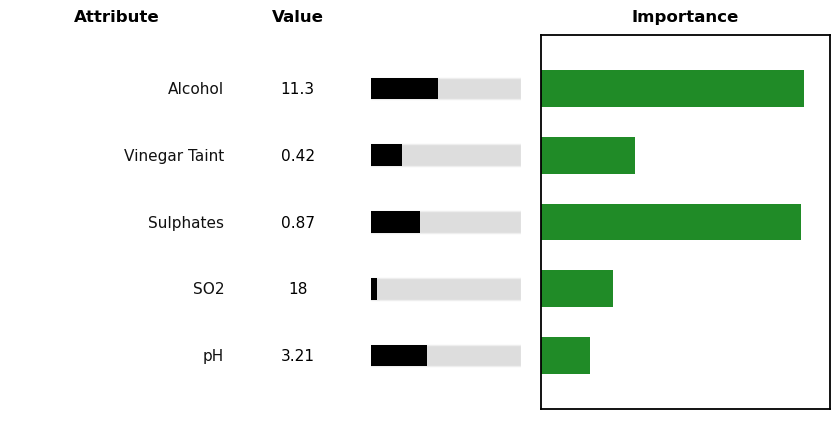

In [34]:
xaikitTest.plot_explanation(
    visualization="importance",
    method="shap",
    phase="testing",
    top_n=5,
    class_labels=["Type 1", "Type 2"],
)


### Participant preview

Reading trials show the explanation. Recall trials show only the feature values.


ipywidgets unavailable. Showing HTML Back/Next preview.


participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
1,1,training,341,shap,False,1
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
1,2,training,1185,shap,False,0
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
1,3,training,1083,shap,False,0
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
1,4,training,1402,shap,False,1
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction
1,5,training,1005,shap,False,1
participantId,trialId,phase,instanceId,xai_method,tested_w_xai,ai_prediction

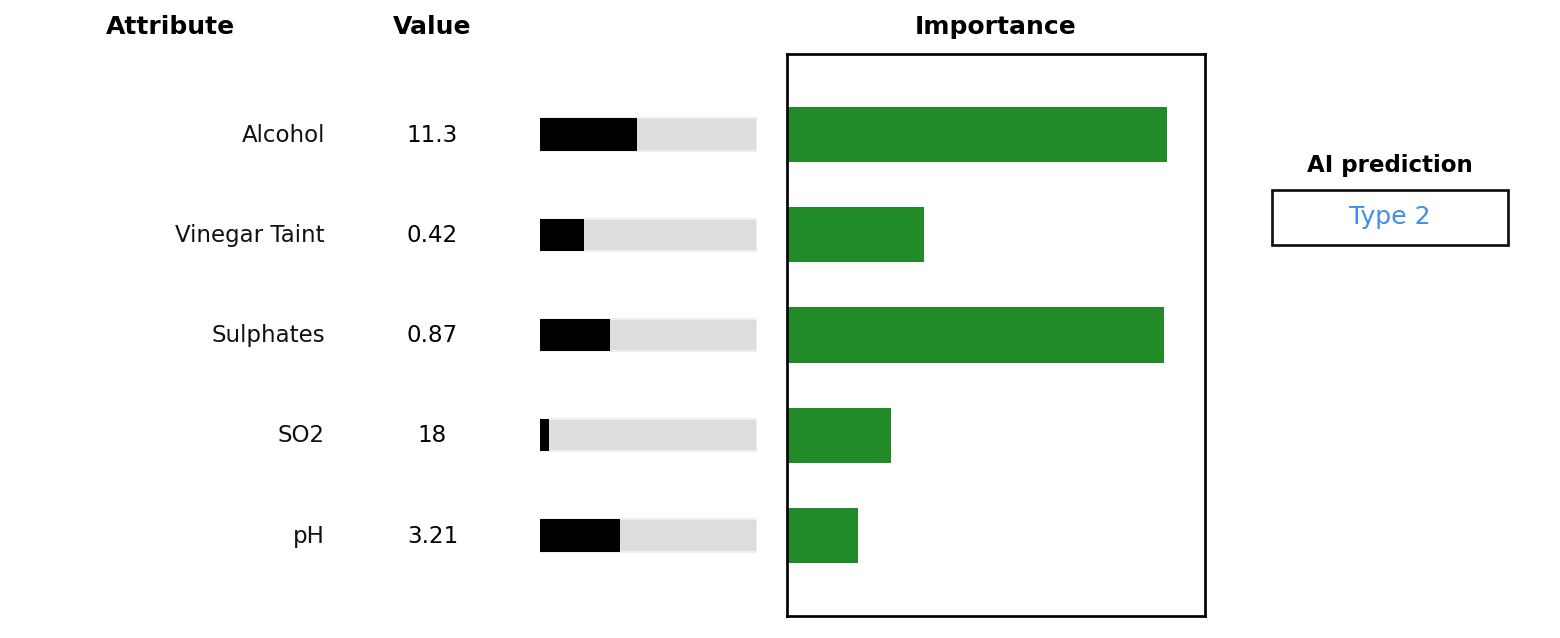
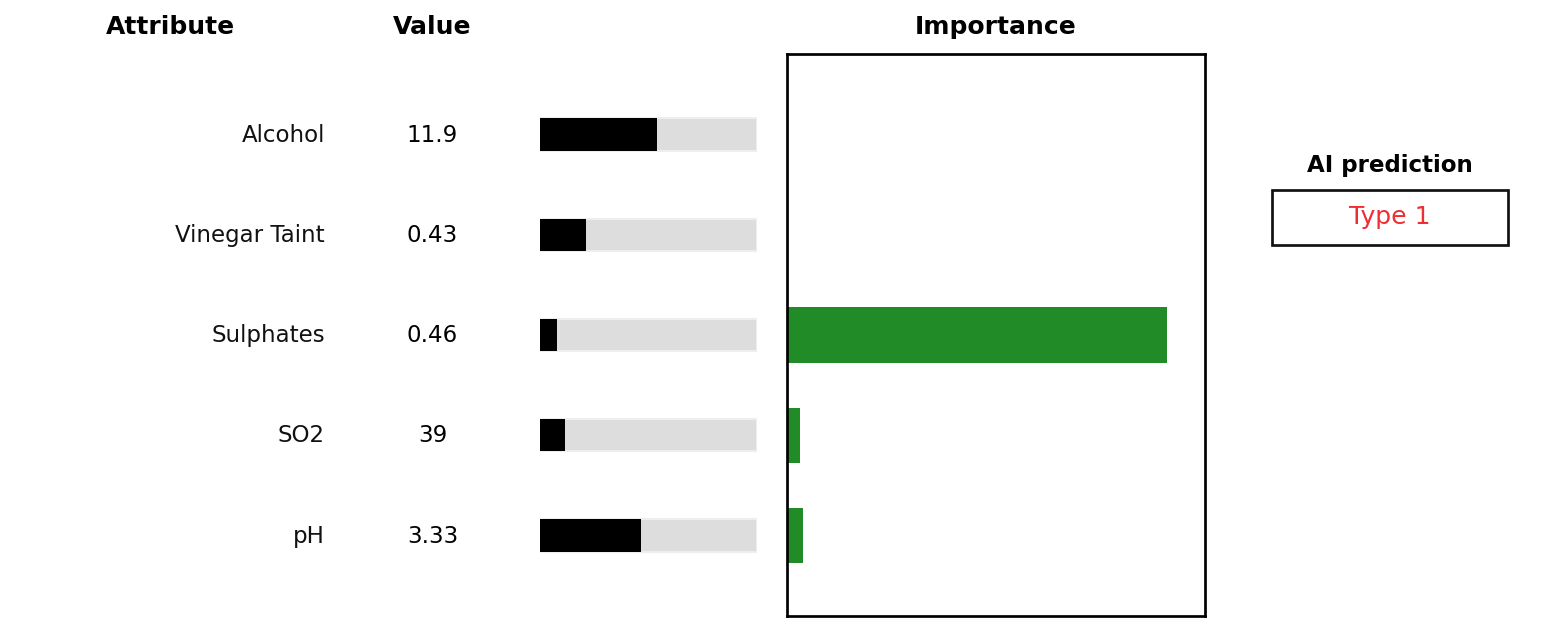
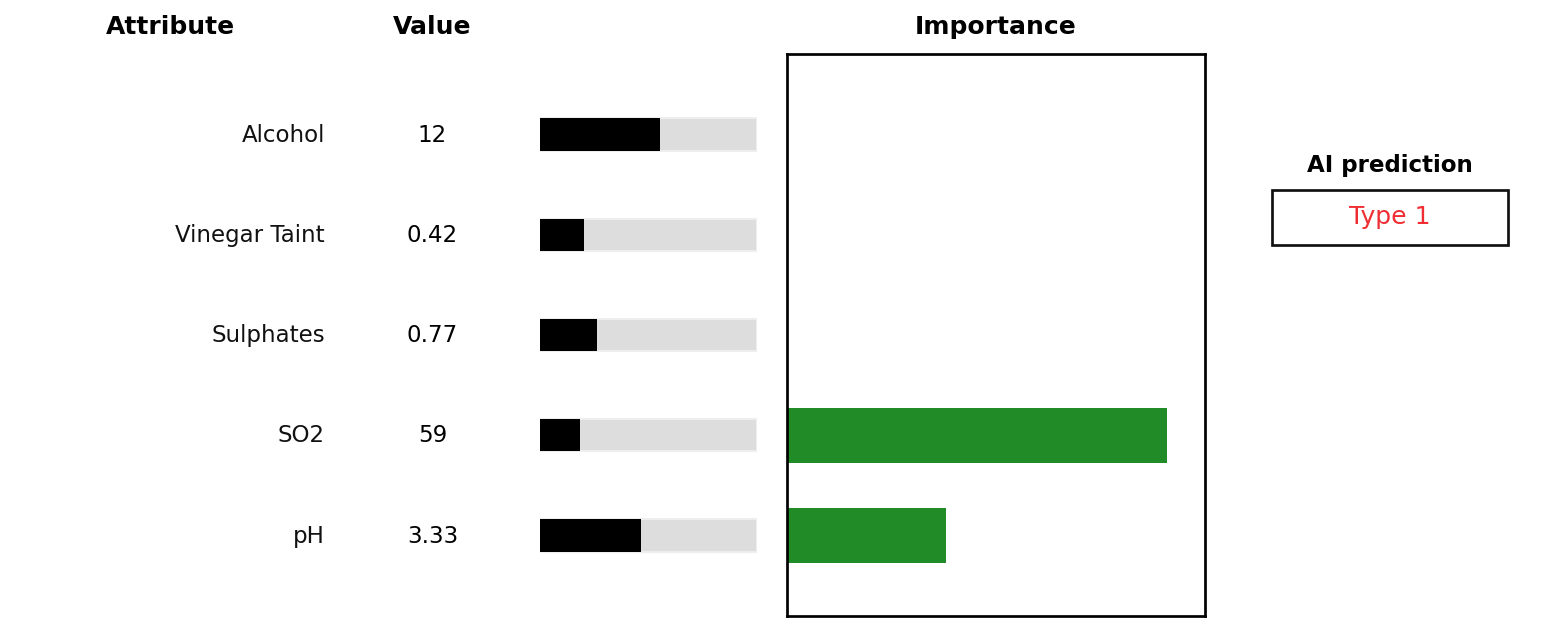
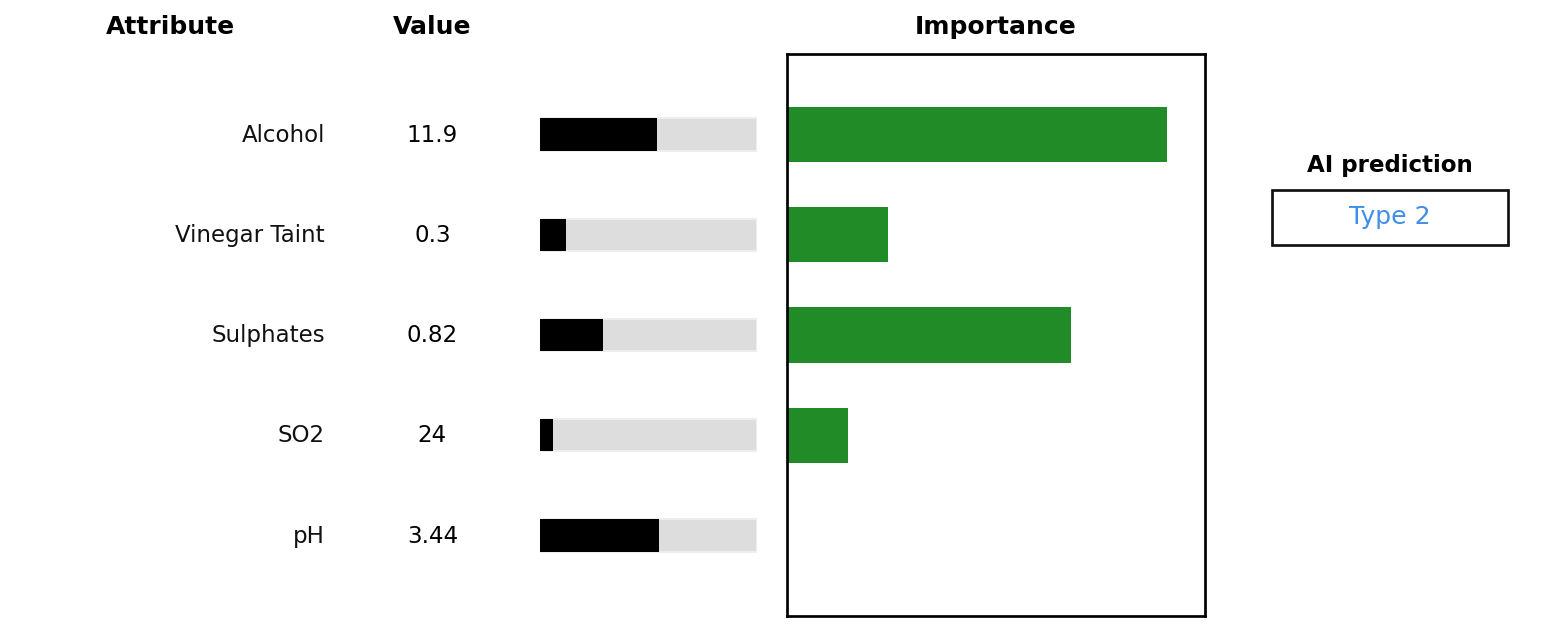
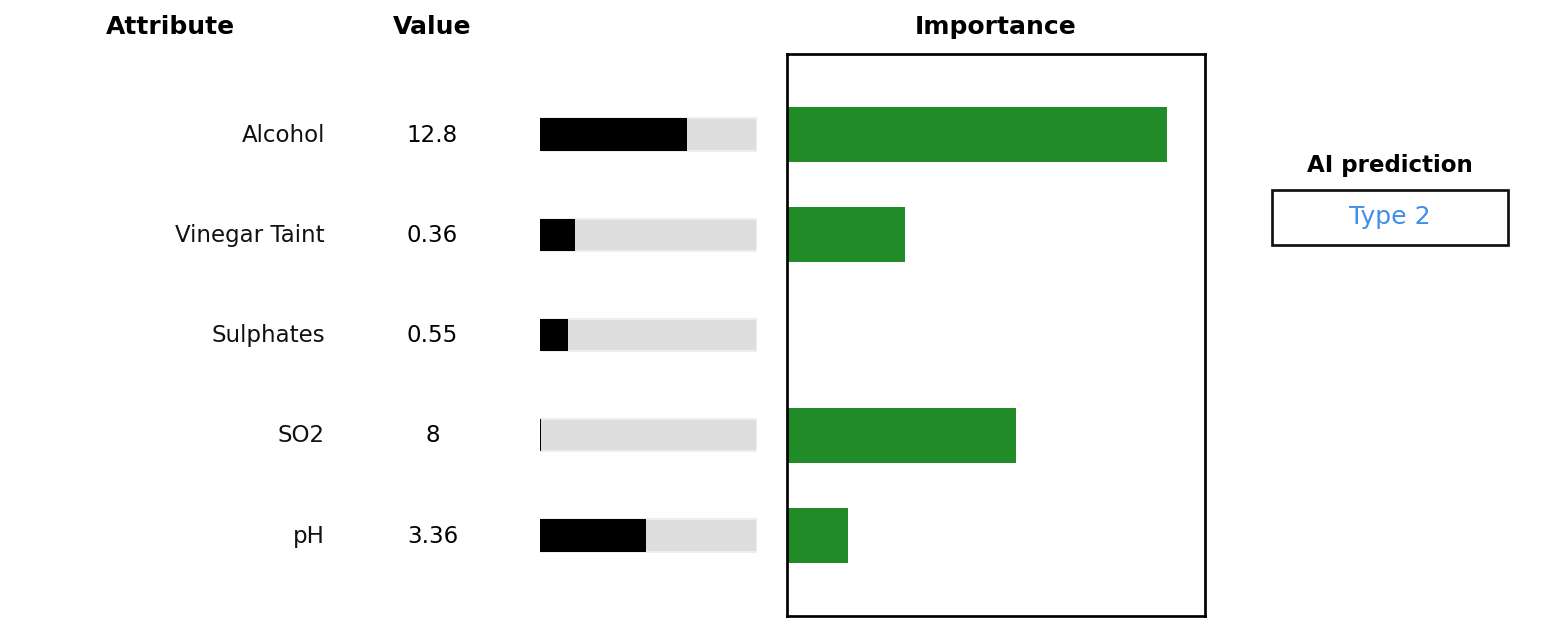
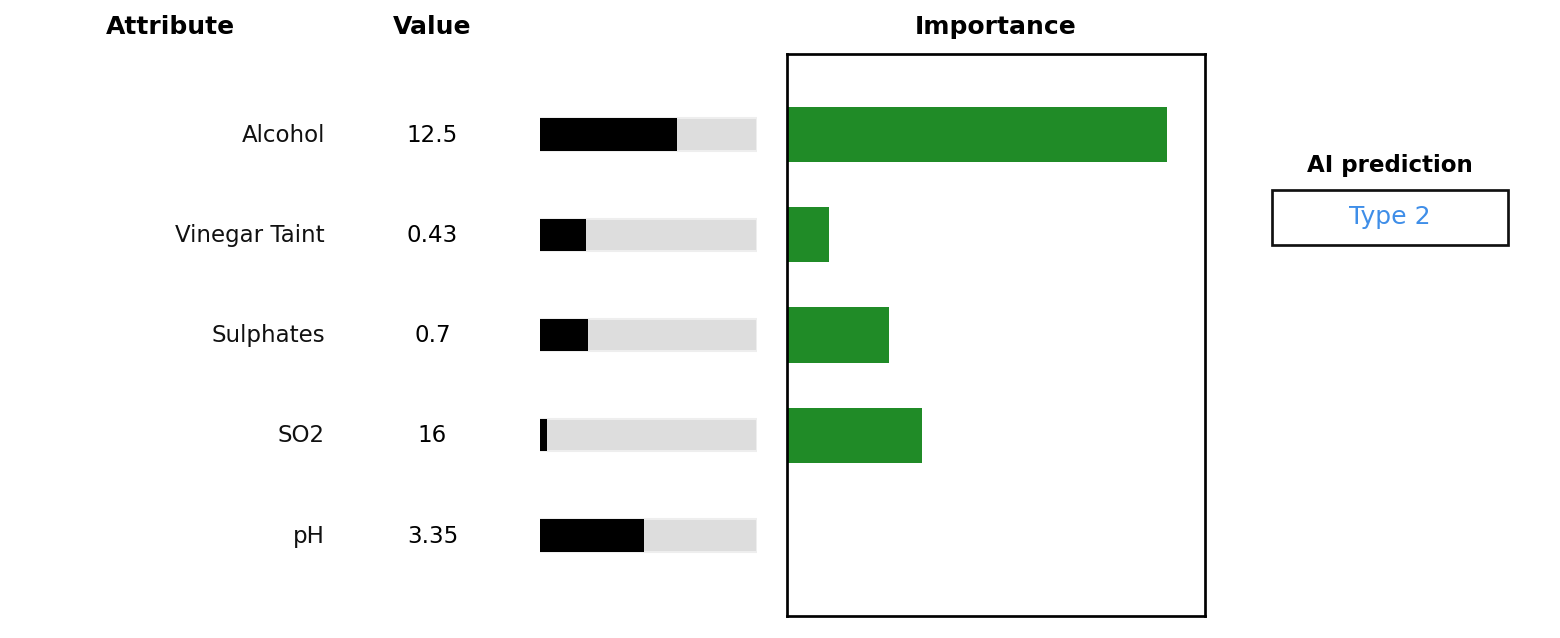
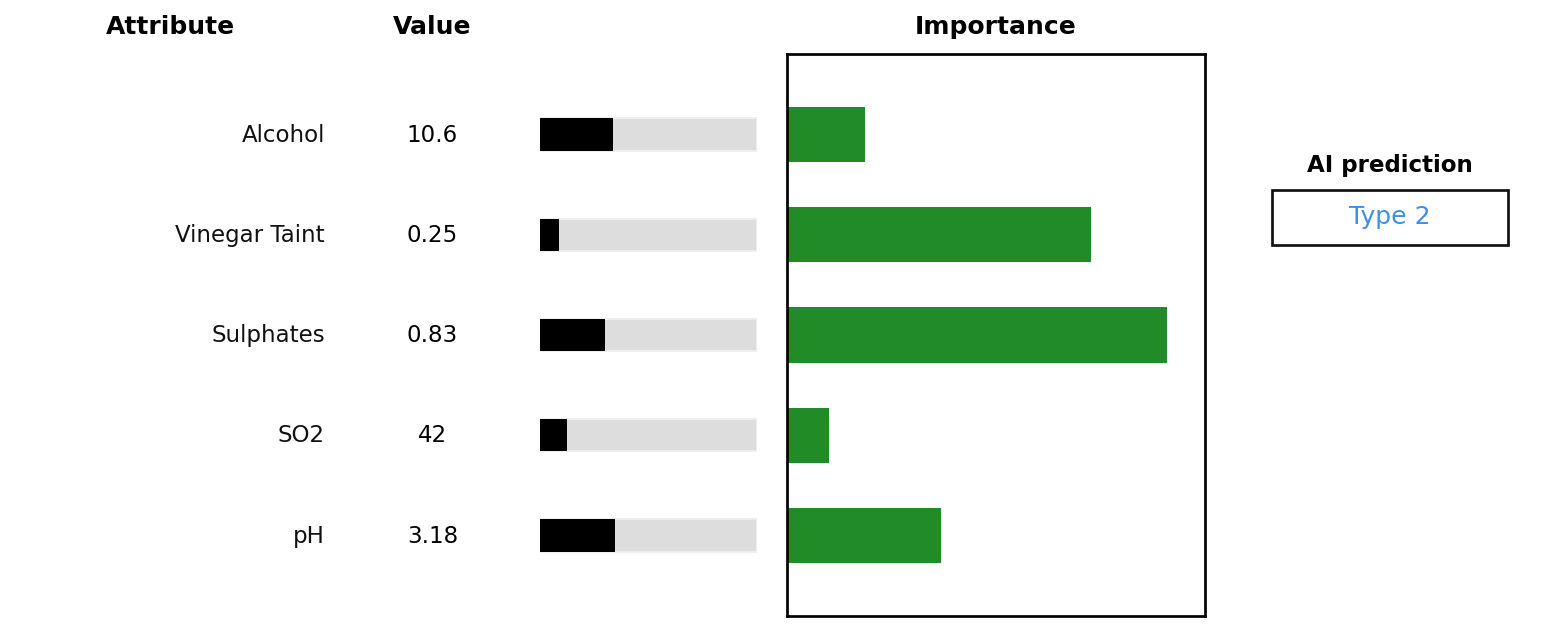
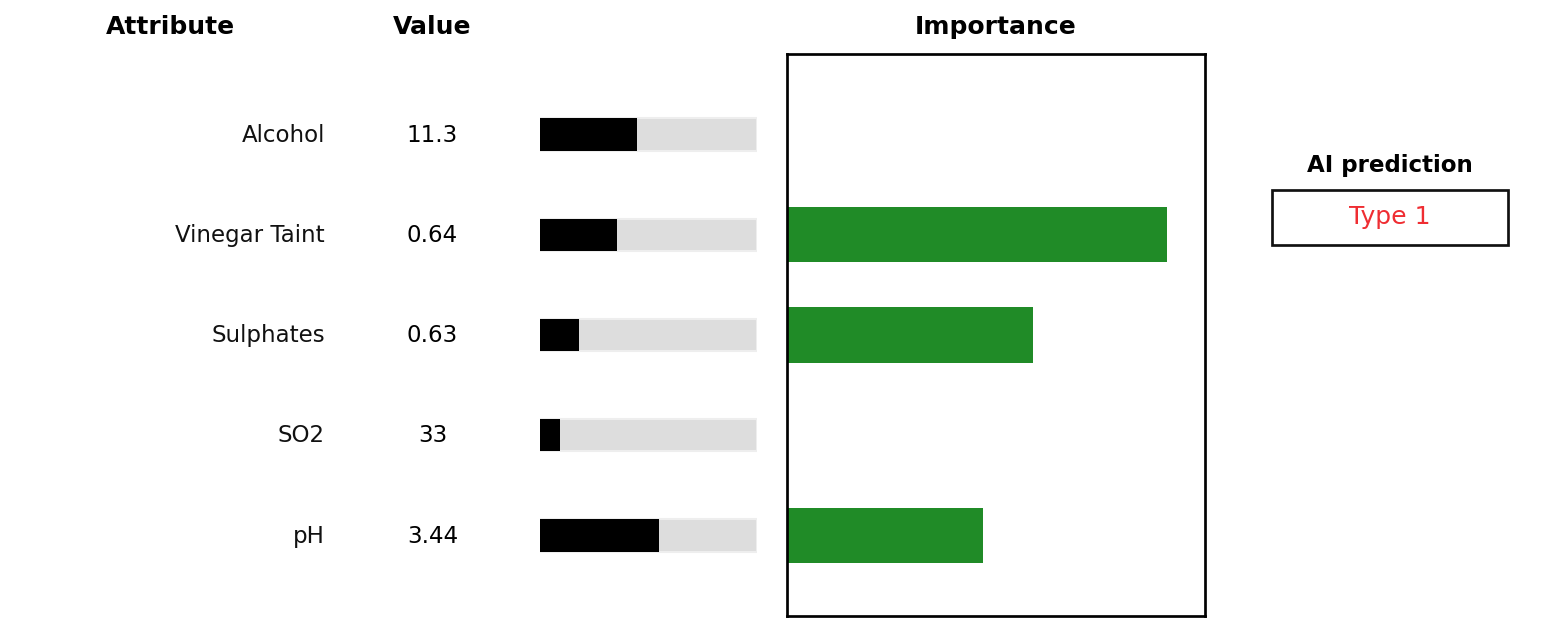
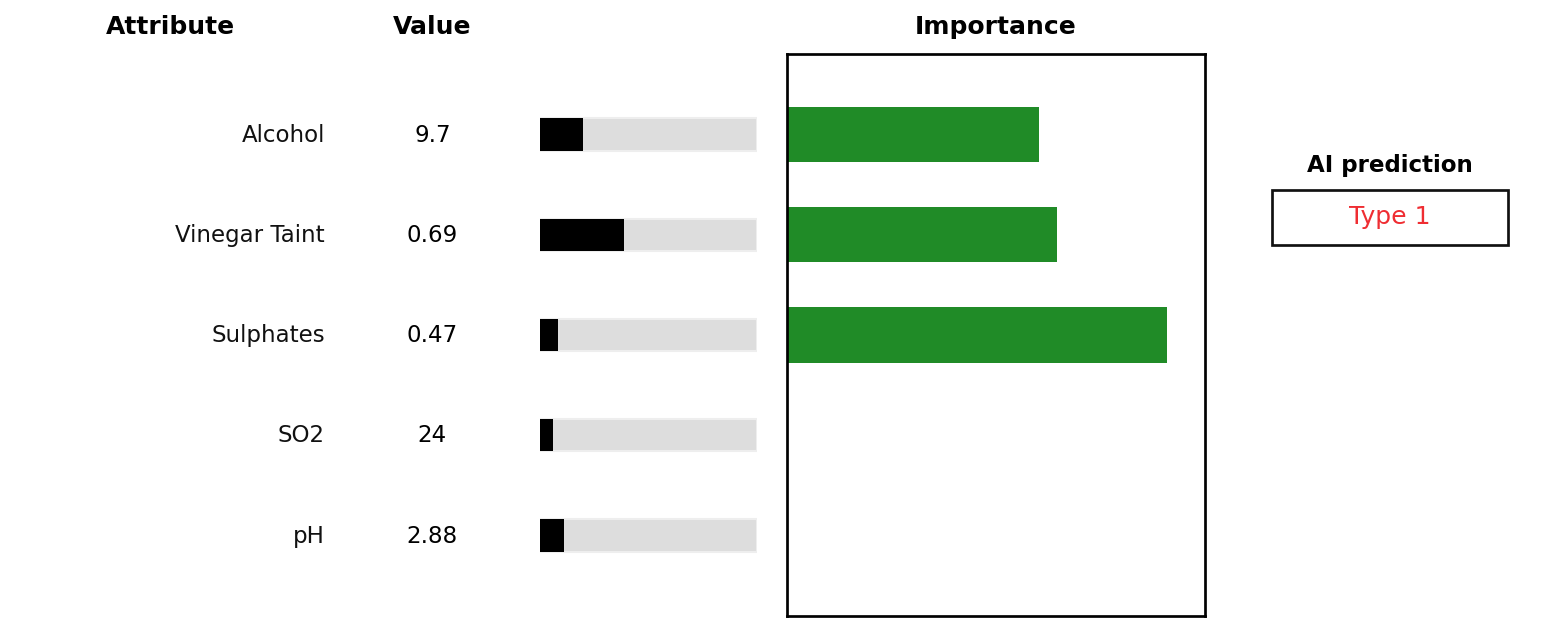
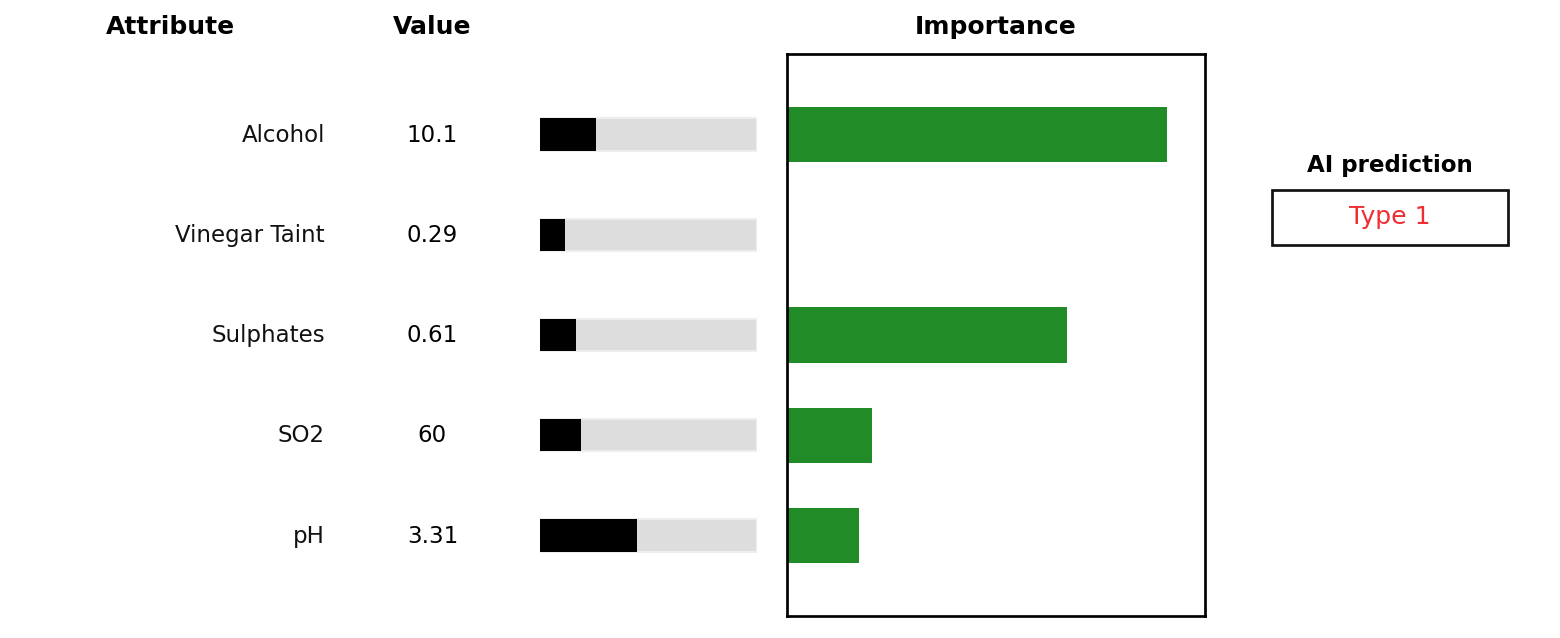
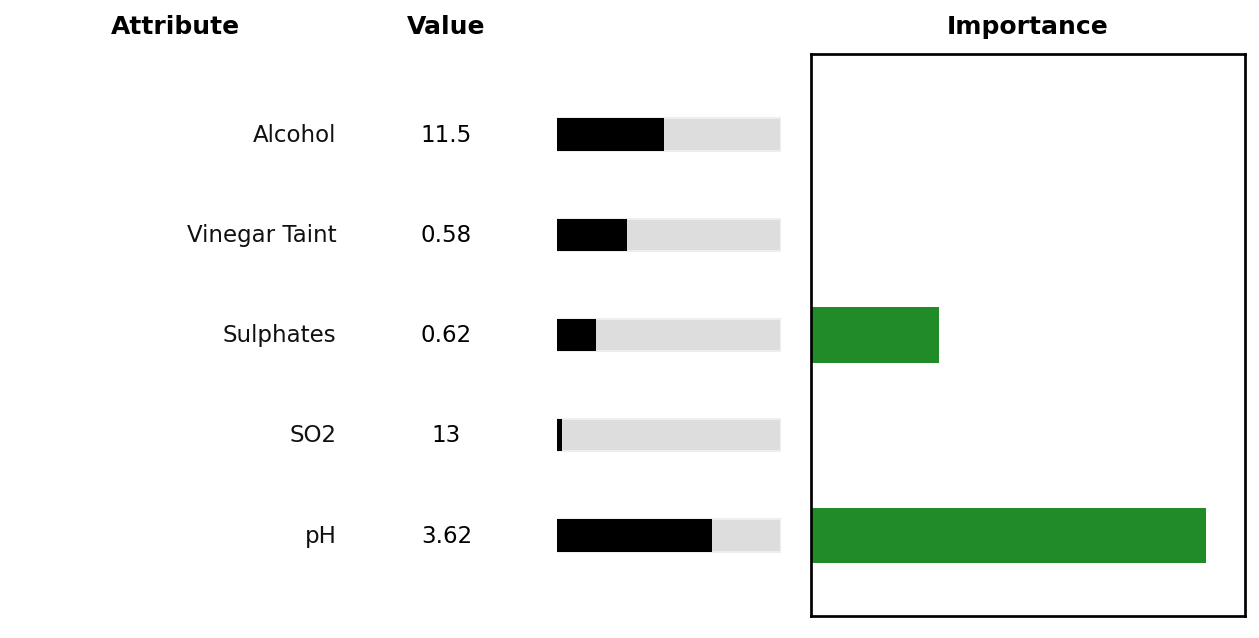
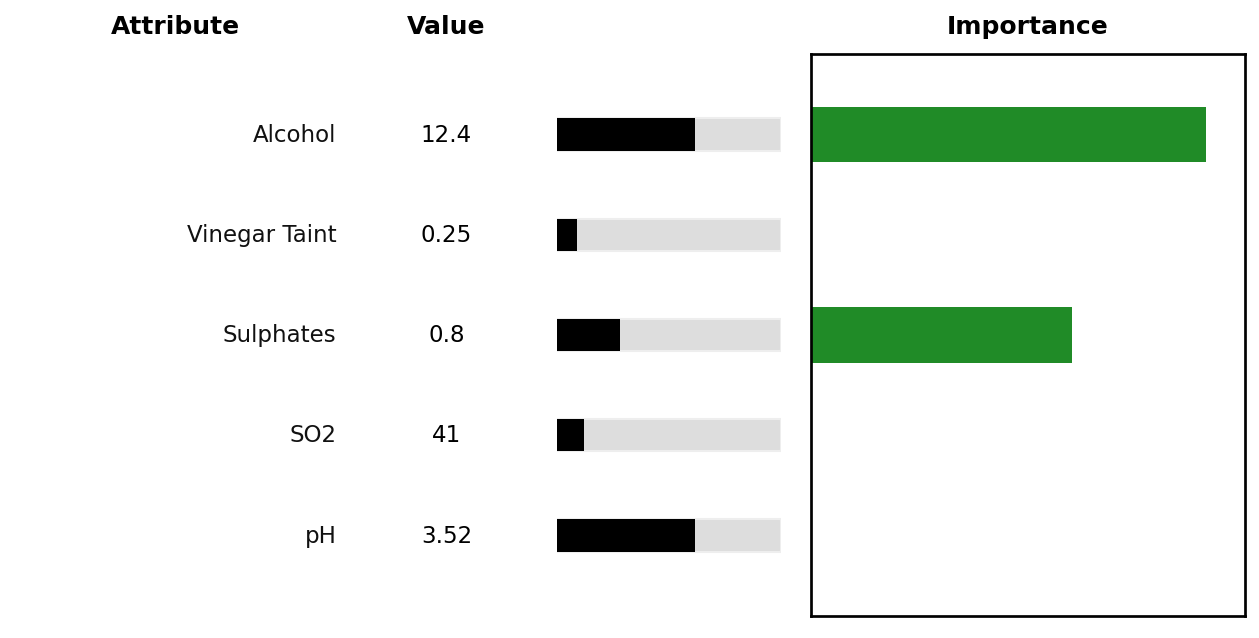
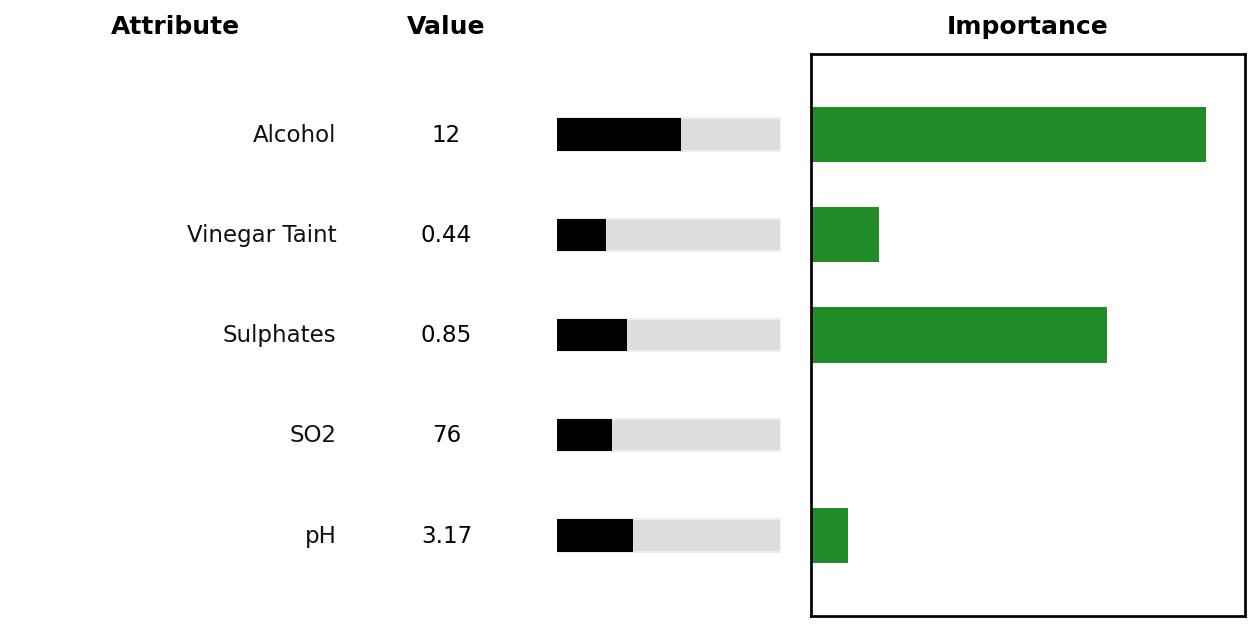
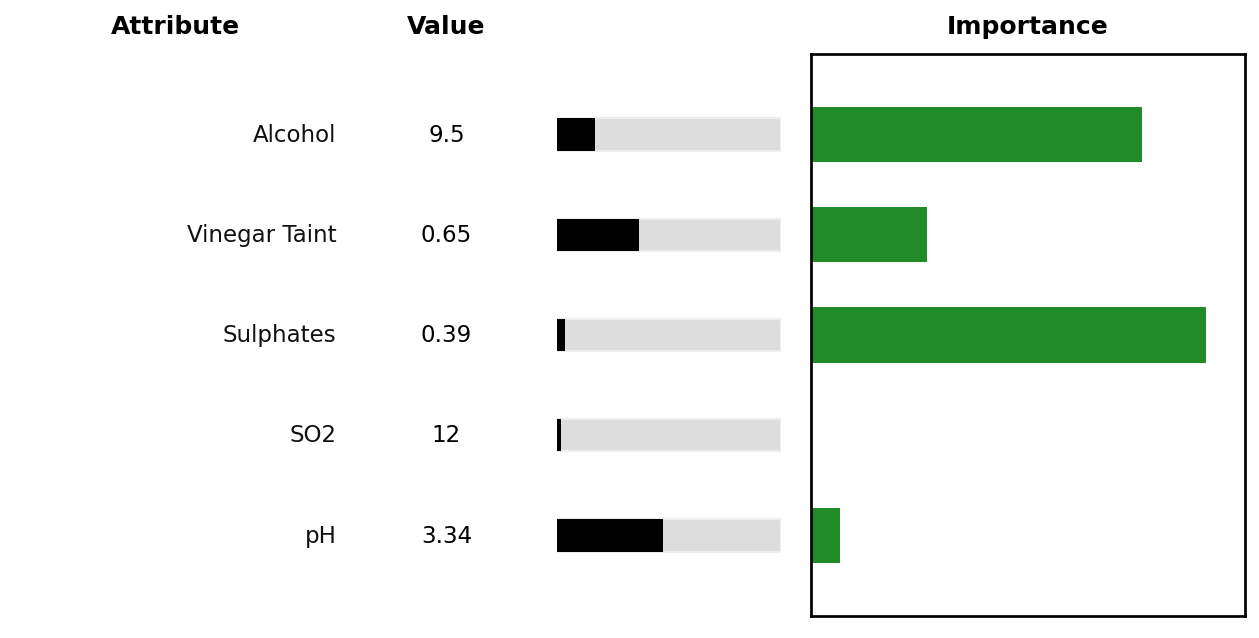
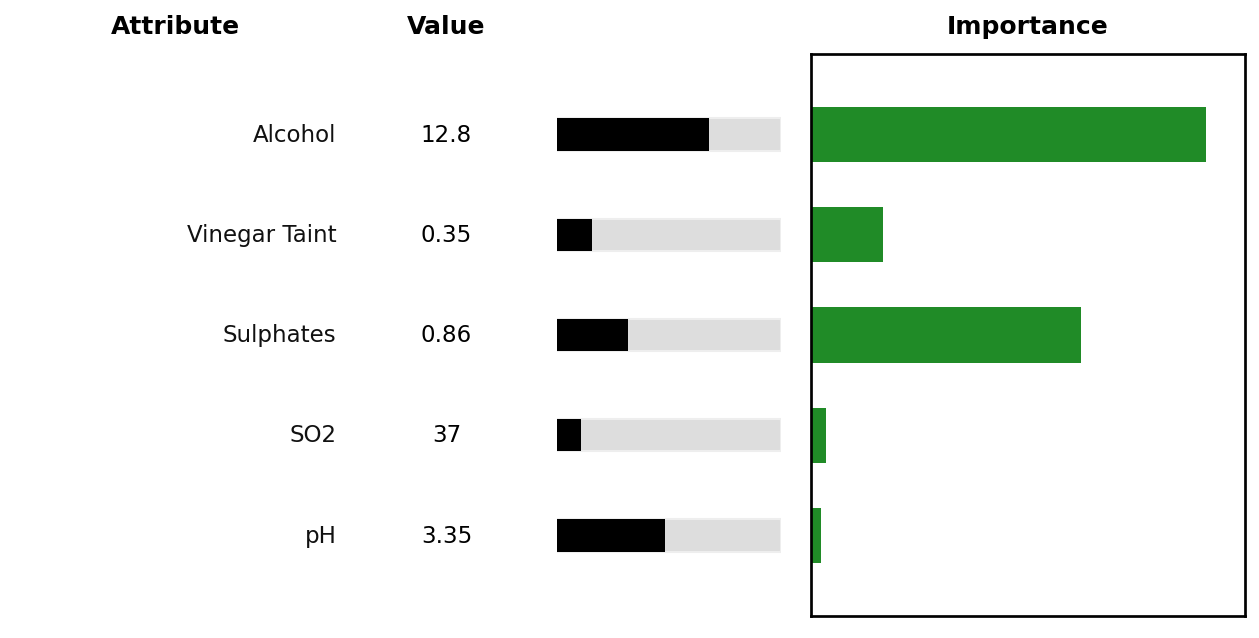
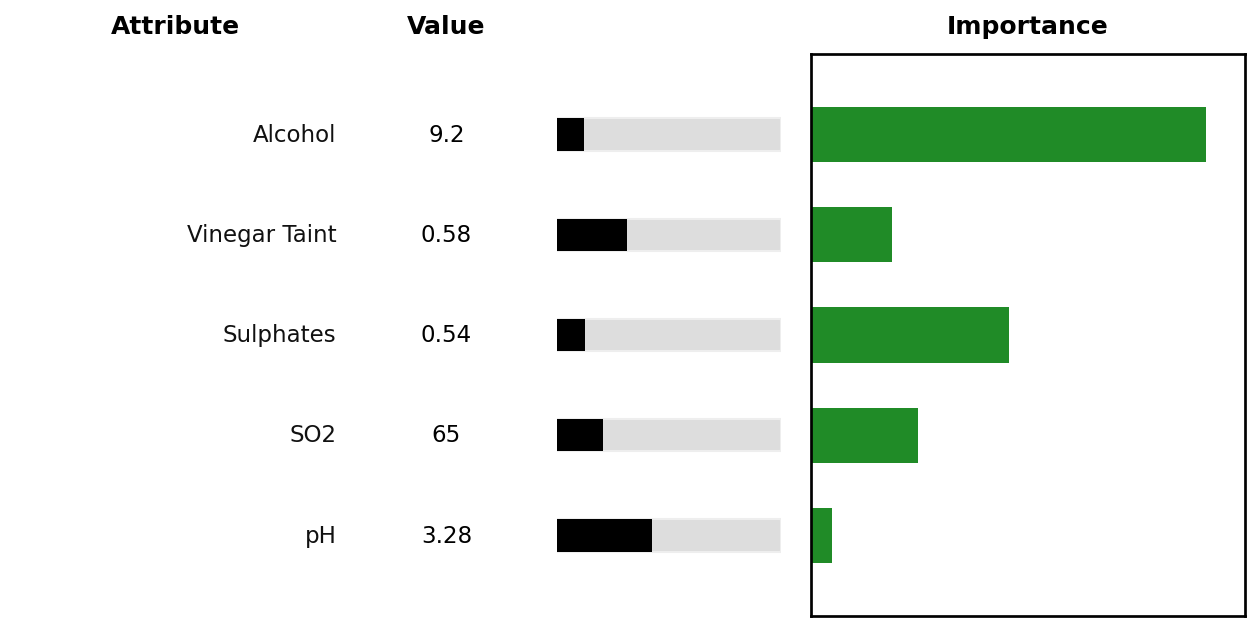
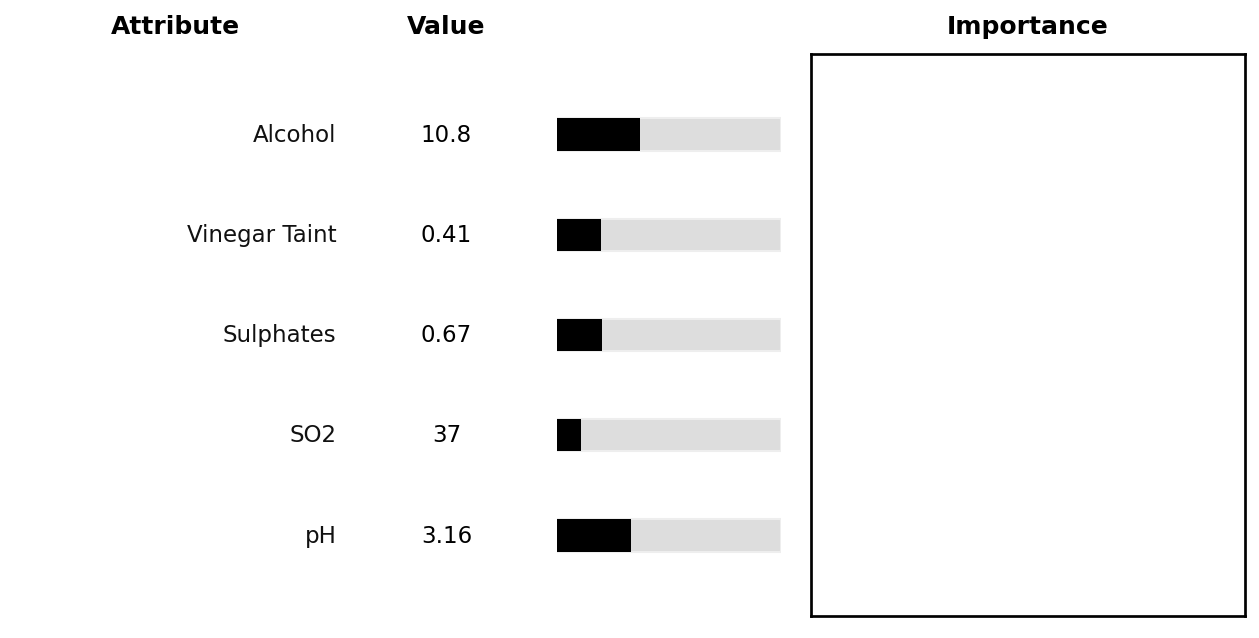
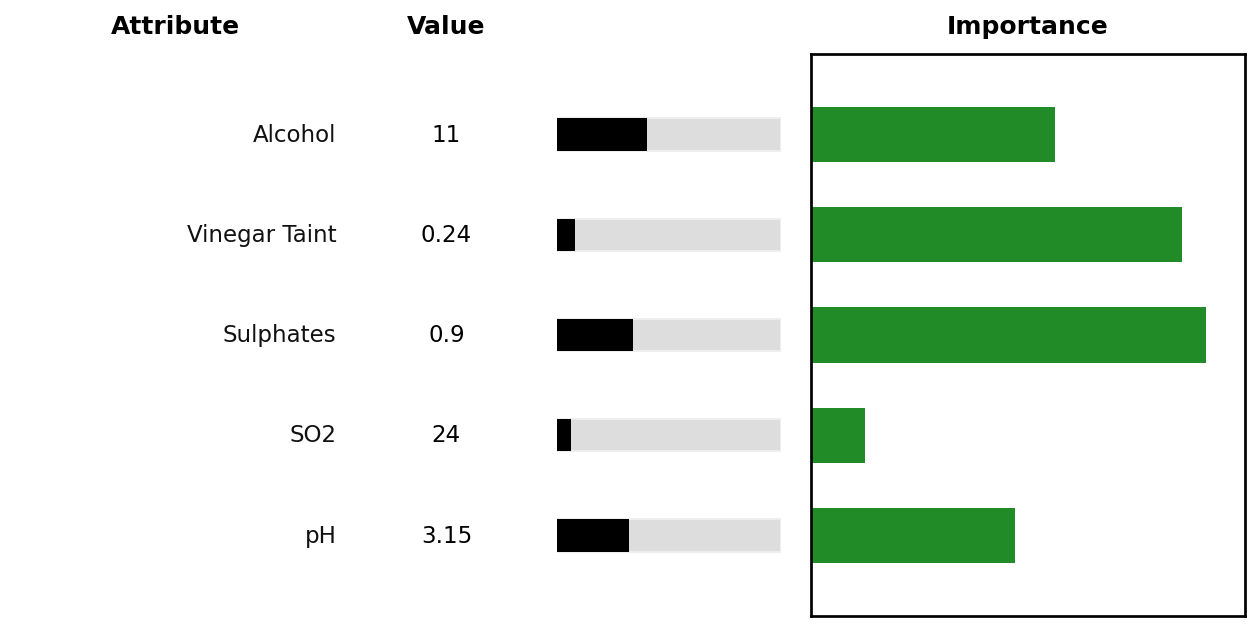
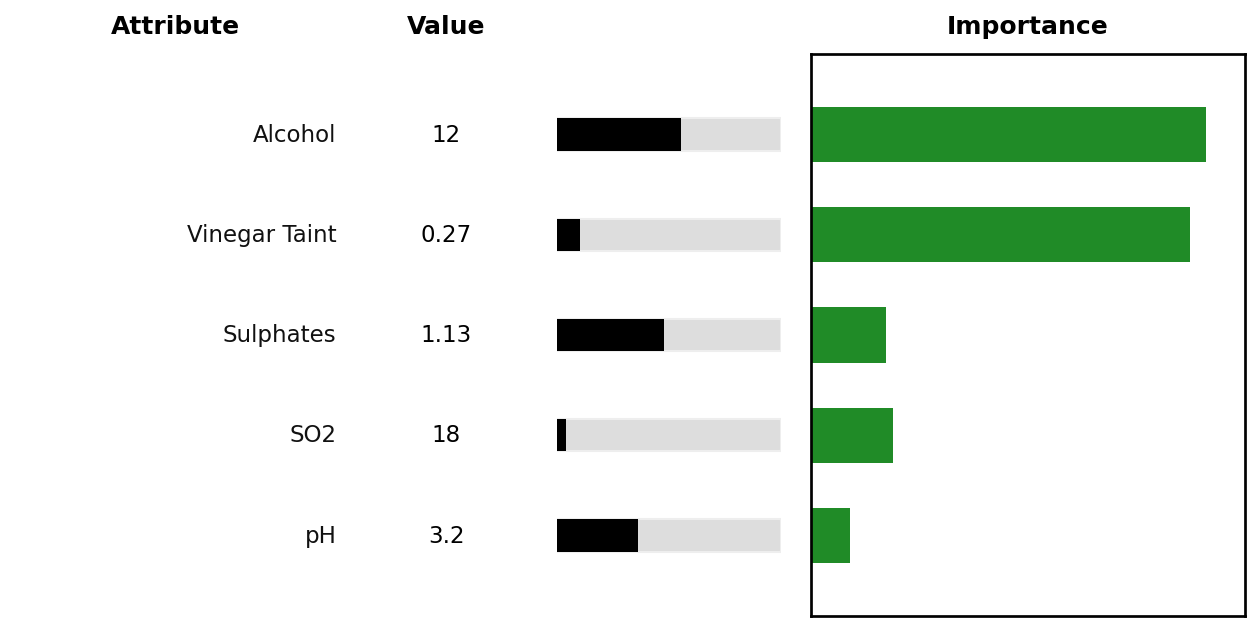
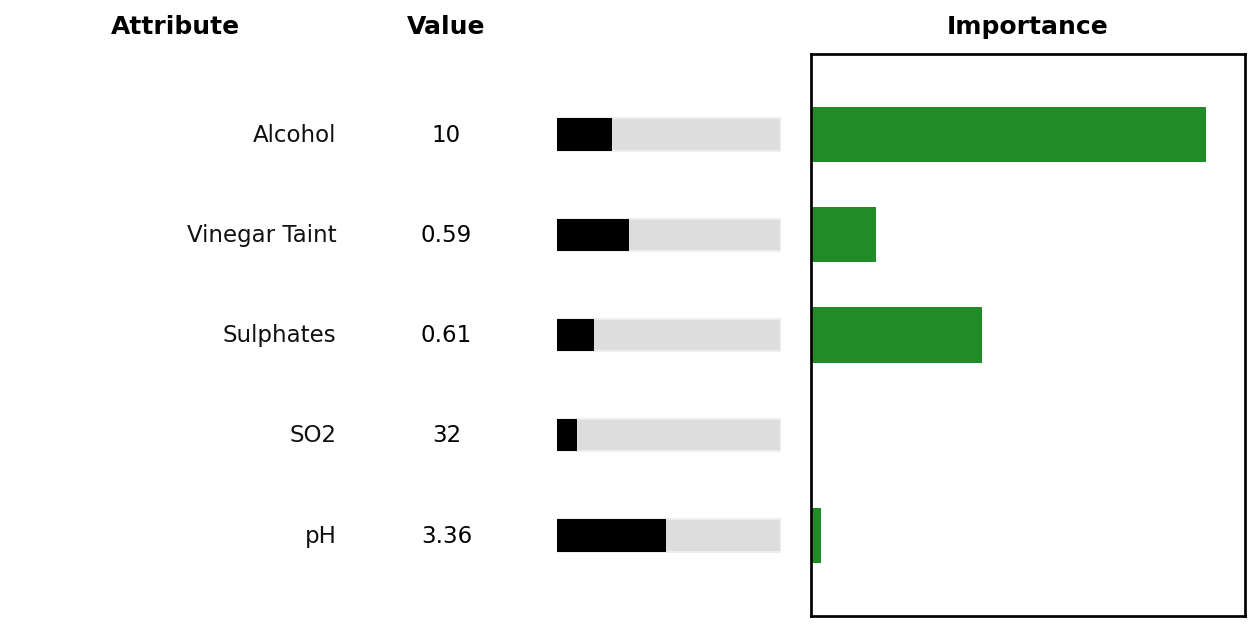

In [35]:
participant_trials = xaikitTest.preview_participant_trials(
    participant_id=1,
    visualization="importance",
    top_n=5,
    class_labels=["Type 1", "Type 2"],
    fallback="html",
)


## Step 9 — Choose a virtual user

The KNN baseline learns from the training examples and predicts labels for new trials. It is fitted separately for each participant-condition.

A fuller model can later add memory decay, limited attention, and different reasoning strategies. Keep KNN as a baseline for comparison.


In [36]:
xaikitTest.set_cognitive_model(
    cognitive_model_id="knn",
    model_kwargs={"n_neighbors": 5},
)


## Step 10 — Run the simulation

Run all conditions and inspect the testing responses.


In [37]:
xaikitTest.validate(stage="execution", show=True)

simulated_results = xaikitTest.run_experiment(
    mode="whole_experiment",
    participant_id=None,
)

testing_responses = simulated_results.query("phase == 'testing'").copy()
display(
    testing_responses[
        [
            "participantId",
            "xai_method",
            "tested_w_xai",
            "agent_prediction",
            "ai_prediction",
            "forward_accuracy",
        ]
    ].head(10)
)


,participantId,xai_method,tested_w_xai,agent_prediction,ai_prediction,forward_accuracy
10,1,shap,False,1.0,1,1.0
11,1,shap,True,1.0,0,0.0
12,1,shap,False,0.0,0,1.0
13,1,shap,True,0.0,1,0.0
14,1,shap,True,0.0,1,0.0
15,1,shap,False,0.0,1,0.0
16,1,shap,False,0.0,0,1.0
17,1,shap,False,1.0,1,1.0
18,1,shap,True,1.0,0,0.0
19,1,shap,False,1.0,1,1.0


In [38]:
sim_csv_path, sim_json_path = xaikitTest.save_results(
    out_dir="experiment_output",
)

print(f"Saved CSV : {sim_csv_path}")
print(f"Saved JSON: {sim_json_path}")


Saved CSV : experiment_output/simulated_results.csv
Saved JSON: experiment_output/simulated_results.json


## Step 11 — Compare conditions

Compare accuracy across explanation methods and Reading/Recall settings. Error bars show the standard error across virtual participants.


Plotted 1 DV(s) × 2 IV(s)


,iv,dv,index,level,count,mean,std,sem
0,xai_method,forward_accuracy,0,lime,25,0.612,0.120139,0.024028
1,xai_method,forward_accuracy,1,lrp,25,0.576,0.127574,0.025515
2,xai_method,forward_accuracy,2,none,25,0.574,0.129196,0.025839
3,xai_method,forward_accuracy,3,shap,25,0.572,0.110000,0.022000
4,tested_w_xai,forward_accuracy,0,False,100,0.584,0.159367,0.015937
5,tested_w_xai,forward_accuracy,1,True,100,0.583,0.169405,0.016940


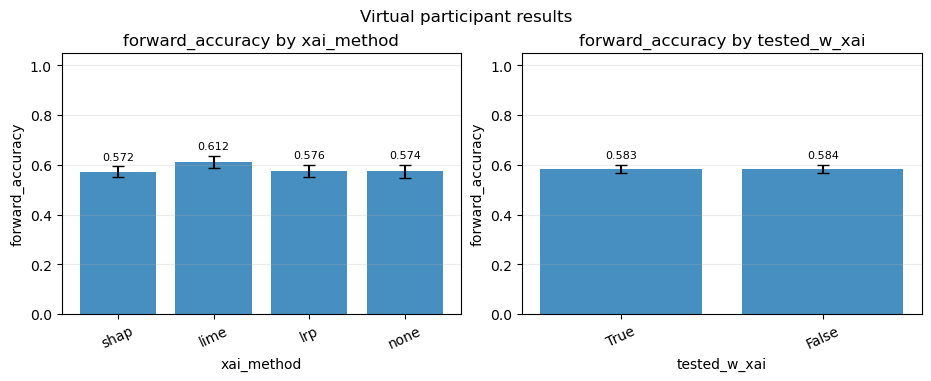

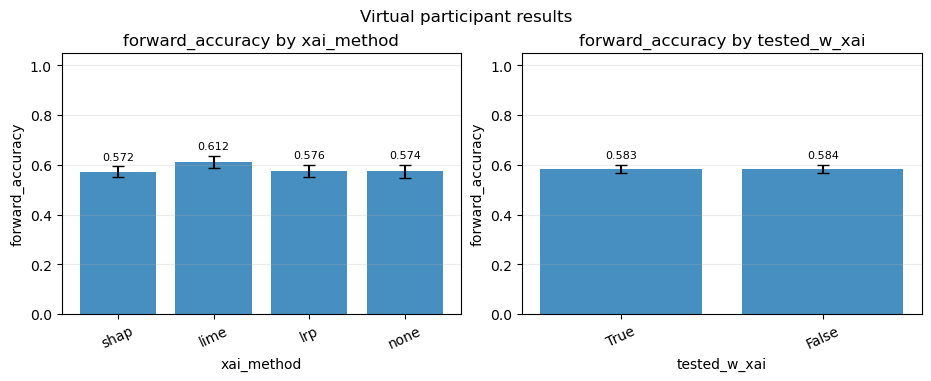

In [39]:
plot_ivs = list(xaikitTest.iv_config)
plot_dvs = list(xaikitTest.DVs)

result_grid = xaikitTest.plot_results_grid(
    responses=simulated_results,
    ivs=plot_ivs,
    dvs=plot_dvs,
    errorbar="sem",
    title="Virtual participant results",
)
print(f"Plotted {len(plot_dvs)} DV(s) × {len(plot_ivs)} IV(s)")
display(result_grid.summary)
result_grid.figure


## Before the human study

- Obtain ethics approval and informed consent.
- Pilot every condition and test the comprehension check.
- Record response time and workload if they are study outcomes.
- Freeze the stimuli, exclusions, sample size, and analysis plan.
